# Assignment_5_KNN_Classification

Apply the KNN algorithm for classification.


## Aim
Apply the K-Nearest Neighbours (KNN) algorithm for classification.

Result folder: /content/results
Accuracy: 0.9333333333333333

Classification Report:
               precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30



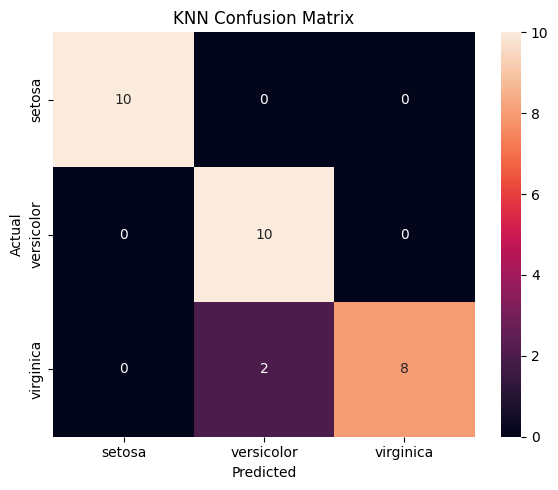

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULT_DIR = "/content/results"
os.makedirs(RESULT_DIR, exist_ok=True)

print("Result folder:", RESULT_DIR)

import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

iris = load_iris()
X_train,X_test,y_train,y_test = train_test_split(
    iris.data, iris.target, test_size=.2, random_state=42, stratify=iris.target)

scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

model=KNeighborsClassifier(n_neighbors=5).fit(X_train,y_train)
pred=model.predict(X_test)

accuracy=accuracy_score(y_test,pred)
print("Accuracy:",accuracy)
print("\nClassification Report:\n",classification_report(y_test,pred,target_names=iris.target_names))

pd.DataFrame(classification_report(
    y_test,pred,target_names=iris.target_names,output_dict=True)).T.to_csv(
    f"{RESULT_DIR}/classification_report.csv")

cm=confusion_matrix(y_test,pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm,annot=True,fmt="d",
            xticklabels=iris.target_names,yticklabels=iris.target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.tight_layout()
plt.savefig(f"{RESULT_DIR}/confusion_matrix.png",dpi=150)
plt.show()


In [ ]:
import shutil
from google.colab import files
shutil.make_archive("/content/Assignment_5_Results","zip",RESULT_DIR)
files.download("/content/Assignment_5_Results.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>